Importar librerias para graficar y integrar para calc. las curvas

In [1]:
import matplotlib.pyplot as plt
import pylab as pl
import numpy as np
from scipy.integrate import solve_ivp

Sistema dinámica que hay que probar que dentro de R posee ciclo límite estable

In [2]:
def dx_dt(t, x):
    dxdt = [-x[1] + x[0]*np.cos(np.pi*x[0]),   # x_punto
             x[0] - x[1]**3]                     # y_punto
    return dxdt

Puntos para integrar y ver la trayectoria

In [41]:
tf = np.linspace(0, 5, 100) #instances donde cada uno tiene una trayectoria - donde se guarda la trayectoria
ic = np.linspace(-1.5, 1.5, 5) #puntos donde se arranca la trayectoria y con esos calculo a donde voy - con eso construyo la tray completa que guardo en tf

Defino el campo vectorial - calculo la dirección de los vectores con el sistema dinamico escribiendolo como u,v:

In [46]:
X, Y = np.mgrid[-1.5:1.5:20j, -1.5:1.5:20j]
u = -Y + X*np.cos(np.pi*X)
v =  X - Y**3

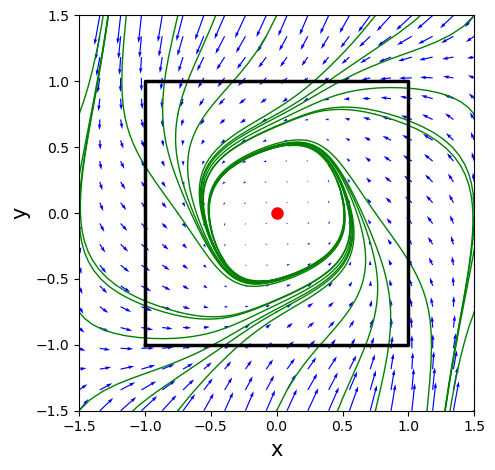

In [53]:
# Calculo las trayectorias integrando en los puntos ic:
for r in ic:
    for s in ic:
        # hacia adelante cada punto calculo como se mueve para adelante y lo ploteo
        xsol = solve_ivp(dx_dt, [0, 5], [r, s], t_eval=tf)
        plt.plot(xsol.y.T[:, 0], xsol.y.T[:, 1], 'g-', linewidth=1)
        # hacia atras - lo mismo pero calculo cuanto es para atras - uso lambda para negar el sistema, no me deja -dx_dt como el ejemplo de apunte 2
        xsol = solve_ivp(lambda t, x: [-v for v in dx_dt(t, x)],
                         [0, 5], [r, s], t_eval=tf)
        plt.plot(xsol.y.T[:, 0], xsol.y.T[:, 1], 'g-', linewidth=1)

# cuadrado región R
cuadrado_x = [-1, 1,  1, -1, -1]
cuadrado_y = [-1, -1, 1,  1, -1]
plt.plot(cuadrado_x, cuadrado_y, 'k-', linewidth=2.5)


# grafico el campo vectorial - en el medio no se ve porque son muy chicos el modulo de los vectores
plt.quiver(X, Y, u, v, color='b', alpha=1)

# pongo el punto inestable
plt.plot(0, 0, 'ro', markersize=8)

# fuentes ejes
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.tick_params(labelsize=10)

# limites de grafico ejes
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)

#para que quede cuadrado y no se solape
plt.gca().set_aspect('equal')
plt.tight_layout()